In [2]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

import yaml


project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
dataset_dir = project_root / "data" / "GTSDB" / "dataset"
class_names = yaml.safe_load((dataset_dir / "data.yaml").read_text(encoding="utf-8"))["names"]


def draw_ground_truth(img_id):
    """Draw every YOLO ground-truth box and its class label for one image."""
    image_stem = f"{int(img_id):05d}"
    image_path = dataset_dir / "images" / f"{image_stem}.png"
    label_path = dataset_dir / "labels" / f"{image_stem}.txt"

    if not image_path.is_file():
        raise FileNotFoundError(f"Image not found: {image_path}")

    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    height, width = image.shape[:2]
    if label_path.is_file():
        label_lines = label_path.read_text(encoding="utf-8").splitlines()
    else:
        label_lines = []

    for line_number, line in enumerate(label_lines, start=1):
        fields = line.split()
        if len(fields) != 5:
            raise ValueError(f"Invalid label at {label_path}:{line_number}")

        class_id, center_x, center_y, box_width, box_height = map(float, fields)
        class_id = int(class_id)
        x1 = int((center_x - box_width / 2) * width)
        y1 = int((center_y - box_height / 2) * height)
        x2 = int((center_x + box_width / 2) * width)
        y2 = int((center_y + box_height / 2) * height)
        class_name = class_names[class_id]
        label = f"{class_id}: {class_name}"

        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        (text_width, text_height), baseline = cv2.getTextSize(
            label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2
        )
        text_y = y1 - 8 if y1 > text_height + 8 else y1 + text_height + 8
        cv2.rectangle(
            image,
            (x1, text_y - text_height - baseline),
            (x1 + text_width, text_y + baseline),
            (0, 255, 0),
            thickness=-1,
        )
        cv2.putText(
            image,
            label,
            (x1, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 0, 0),
            2,
            cv2.LINE_AA,
        )

    plt.figure(figsize=(16, 9))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f"Ground truth: {image_stem}.png ({len(label_lines)} boxes)")
    plt.axis("off")
    plt.show()

    return image

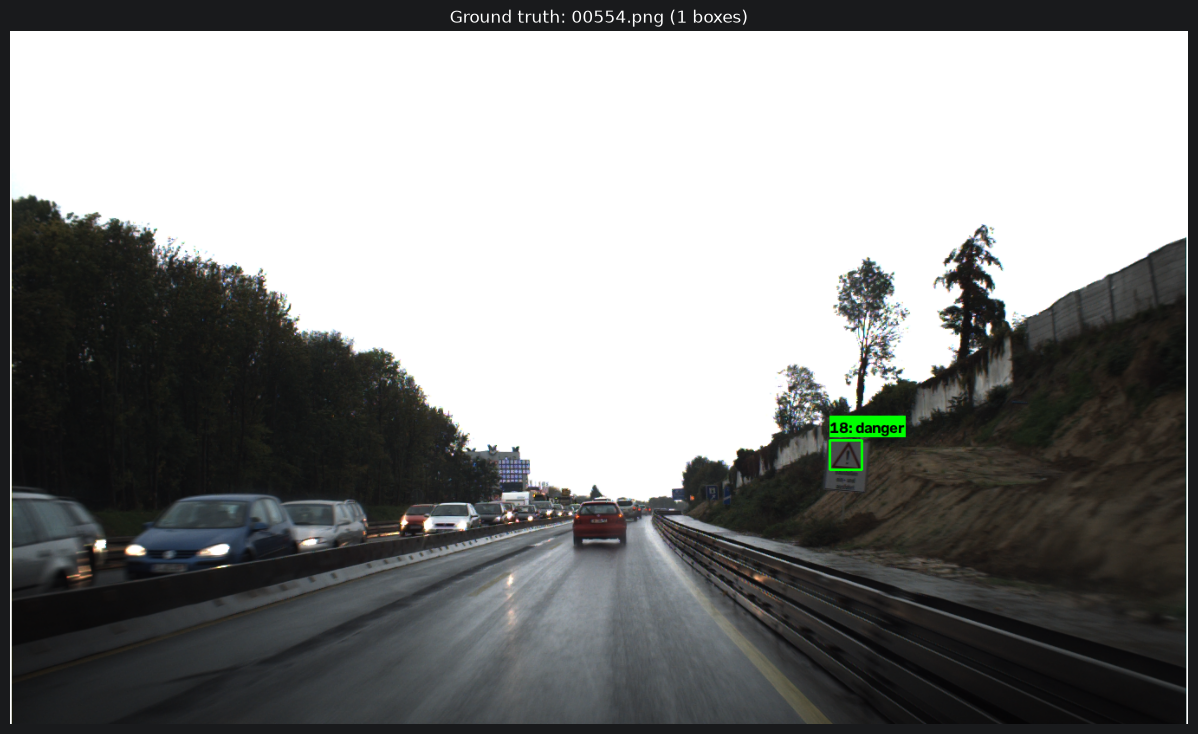

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [  0,  25,  24],
        ...,
        [ 15,  13,   0],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [  0,  24,  22],
        ...,
        [ 14,  13,   0],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [  0,  23,  22],
        ...,
        [ 14,  13,   0],
        [255, 255, 255],
        [255, 255, 255]]

In [23]:
draw_ground_truth(554)